# Cafe Sales: Data Cleaning and 10 KPIs

Session 04. Topic 1 / Programming Fundamentals (Part A).

Dataset: [cafe sales dirty data](https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training).
10,000 transactions from 2023, deliberately corrupted. The CSV is in `data/` so this runs
without Kaggle credentials.

69% of rows have at least one broken cell, but 99.8% are still usable for revenue. Most
missing values can be calculated back from the other columns, so deleting the broken rows
would have thrown away two thirds of the revenue.

## 0. Setup

No output from this cell. Imports and function definitions change what Python knows, not
what is on screen. Run it first, and again after any kernel restart.

In [1]:
# Setup only, no output.

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)

BLUE, GREY, ORANGE = "#3B6EA8", "#B8BFC7", "#D98A3A"


def bar(labels, values, title, ylabel="Revenue", rotate=0, colors=None, fmt="{:,.0f}"):
    fig, ax = plt.subplots(figsize=(9, 4.2))
    bars = ax.bar([str(x) for x in labels], values, color=colors or BLUE)
    ax.set_title(title, fontsize=12, weight="bold", loc="left")
    ax.set_ylabel(ylabel)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="x", rotation=rotate)
    ax.margins(y=0.15)
    for b, v in zip(bars, values):
        ax.annotate(fmt.format(v), (b.get_x() + b.get_width() / 2, v),
                    ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

## 1. Load the raw file

Read everything as text. If pandas guesses the types, one `"ERROR"` cell turns the whole
column into text anyway and the problem is hidden. Converting later, explicitly, gives
control over what happens to the bad values.

In [2]:
RAW_TO_SNAKE = {
    "Transaction ID": "transaction_id",
    "Item": "item",
    "Quantity": "quantity",
    "Price Per Unit": "price_per_unit",
    "Total Spent": "total_spent",
    "Payment Method": "payment_method",
    "Location": "location",
    "Transaction Date": "transaction_date",
}

NUMERIC_COLS = ["quantity", "price_per_unit", "total_spent"]
DIMENSION_COLS = ["item", "payment_method", "location"]
UNKNOWN_LABEL = "Unknown"
MONEY_TOLERANCE = 0.01     # float comparison guard for total == qty * price

raw = pd.read_csv("data/dirty_cafe_sales.csv", dtype=str).rename(columns=RAW_TO_SNAKE)
print(raw.shape)
raw.head(8)

(10000, 8)


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28


## 2. What is actually broken

Two kinds of missing value are mixed together:

- **Blanks**, empty cells. `isna()` finds these.
- **Sentinels**, the text `"ERROR"` or `"UNKNOWN"`. Not empty, so `isna()` misses them.

Sentinels are the dangerous kind. Until they become real nulls every count is wrong, and
`UNKNOWN` turns up in the KPIs as if it were a real product.

In [3]:
sentinels = pd.DataFrame({
    "blank": raw.isna().sum(),
    "literal_ERROR": (raw == "ERROR").sum(),
    "literal_UNKNOWN": (raw == "UNKNOWN").sum(),
})
sentinels["total_bad"] = sentinels.sum(axis=1)
sentinels["pct_of_rows"] = (sentinels["total_bad"] / len(raw) * 100).round(2)
sentinels.sort_values("pct_of_rows", ascending=False)

,blank,literal_ERROR,literal_UNKNOWN,total_bad,pct_of_rows
location,3265,358,338,3961,39.61
payment_method,2579,306,293,3178,31.78
item,333,292,344,969,9.69
price_per_unit,179,190,164,533,5.33
total_spent,173,164,165,502,5.02
quantity,138,170,171,479,4.79
transaction_date,159,142,159,460,4.60
transaction_id,0,0,0,0,0.00


Three things from that table:

- `transaction_id` is 100% complete, so the duplicate check is trustworthy.
- `location` (39.6%) and `payment_method` (31.8%) are 71% of all the missing cells.
- Those two are also the only columns I cannot rebuild. `quantity`, `price_per_unit` and
  `total_spent` are numbers with a fixed relationship, so one can be recalculated from the
  other two. `location` and `payment_method` are labels. Nothing else in the row implies
  them, so a missing `Takeaway` is gone for good.

Next: check whether the text values are written inconsistently (`in-store` vs `In-Store`),
which would split one group into several in a `groupby`.

In [4]:
for col in DIMENSION_COLS:
    vals = raw[col].dropna().unique()
    collapsed = pd.Series([v.strip().lower() for v in vals]).nunique()
    padded = any(v != v.strip() for v in vals)
    print(f"{col:16} distinct={len(vals):2}  after lower+strip={collapsed:2}  padded_with_spaces={padded}")

item             distinct=10  after lower+strip=10  padded_with_spaces=False
payment_method   distinct= 5  after lower+strip= 5  padded_with_spaces=False
location         distinct= 4  after lower+strip= 4  padded_with_spaces=False


Nothing to merge. Lowercasing and trimming does not reduce the distinct count, so the
values are already consistent. I still standardise them when cleaning, in case the till
starts writing `in-store` later.

## 3. The cleaning steps

Each step is its own function, so I can run them one at a time and see what changed. They
all copy the input and return a new DataFrame, so re-running a cell cannot corrupt the
earlier results.

In [5]:
# Definitions only, no output. These run in step 4.

SENTINELS = ("ERROR", "UNKNOWN", "N/A", "NA", "NONE", "NULL", "")


def normalise_sentinels(df):
    out = df.copy()
    for col in out.columns:
        stripped = out[col].astype("string").str.strip()
        out[col] = stripped.mask(stripped.str.upper().isin(SENTINELS))
    return out


def standardise_strings(df):
    out = df.copy()
    for col in DIMENSION_COLS:
        out[col] = out[col].str.replace(r"\s+", " ", regex=True).str.title()
    out["transaction_id"] = out["transaction_id"].str.upper()
    return out


def coerce_types(df):
    out = df.copy()
    for col in NUMERIC_COLS:
        # coerce means bad values become NaN instead of raising, so they can be
        # dealt with later rather than stopping the run.
        out[col] = pd.to_numeric(out[col], errors="coerce")
    out["transaction_date"] = pd.to_datetime(
        out["transaction_date"], format="%Y-%m-%d", errors="coerce"
    )
    return out

### Why the repair works

Two things hold in this data, both checked below rather than assumed:

1. Each item always has the same price, so a missing price can be looked up from the item.
2. `total_spent` always equals `quantity * price_per_unit`, so any one of the three can be
   rebuilt from the other two.

The second one matters. If even a few rows disagreed it would mean discounts or refunds
exist, and multiplying to fill in totals would invent revenue.

In [6]:
# Definitions only, no output. These run in step 4.

def learn_menu(df):
    # Read the menu out of the data instead of hard-coding it, so a price change
    # does not silently break the lookup.
    pairs = df.dropna(subset=["item", "price_per_unit"])
    menu = {}
    for item, prices in pairs.groupby("item")["price_per_unit"].unique().items():
        if len(prices) == 1:
            menu[str(item)] = float(prices[0])
        else:
            print(f"warning: {item} has {len(prices)} different prices, skipping")
    return menu


def recover_price_from_item(df, menu):
    out = df.copy()
    out["price_per_unit"] = out["price_per_unit"].fillna(out["item"].map(menu))
    return out


def recover_arithmetic(df):
    """Rebuild whichever of quantity / price / total is missing from the other two."""
    out = df.copy()
    qty, price, total = out["quantity"], out["price_per_unit"], out["total_spent"]
    out["total_spent"] = total.fillna(qty * price)
    out["quantity"] = qty.fillna((total / price).where(price.notna() & (price != 0)))
    out["price_per_unit"] = price.fillna((total / qty).where(qty.notna() & (qty != 0)))
    return out


def recover_item_from_price(df, menu):
    """Only fills the name where the price points at one item. 3.00 is Cake or Juice
    and 4.00 is Sandwich or Smoothie, so those stay unknown rather than guessed."""
    out = df.copy()
    by_price = {}
    for item, price in menu.items():
        by_price.setdefault(price, []).append(item)
    unique = {p: items[0] for p, items in by_price.items() if len(items) == 1}
    ambiguous = {p: sorted(i) for p, i in by_price.items() if len(i) > 1}
    if ambiguous:
        print(f"prices matching more than one item, left unknown: {ambiguous}")
    out["item"] = out["item"].fillna(out["price_per_unit"].map(unique).astype("string"))
    return out

### Flags instead of deletions

Broken rows are labelled, not deleted, and each KPI filters on the flag it needs.

A row can be broken for one question and fine for another. A sale with no date still counts
towards revenue, it just cannot appear in the day-of-week KPIs.

Missing labels become `"Unknown"` and the row stays. With 39.6% of locations missing,
dropping those rows would delete most of the data.

In [7]:
# Definitions only, no output. These run in step 4.

def flag_validity(df):
    out = df.copy()
    qty, price, total = out["quantity"], out["price_per_unit"], out["total_spent"]
    out["has_revenue"] = total.notna() & (total >= 0)
    out["has_valid_date"] = out["transaction_date"].notna()
    out["has_valid_quantity"] = qty.notna() & (qty > 0)
    out["is_arithmetic_consistent"] = (
        ((total - qty * price).abs() <= MONEY_TOLERANCE).fillna(False).astype(bool)
    )
    # Usable for a revenue-by-product-by-day report: every value real and consistent.
    out["is_valid"] = (
        out["has_revenue"] & out["has_valid_date"] & out["has_valid_quantity"]
        & out["is_arithmetic_consistent"] & out["item"].notna()
    )
    return out


def apply_null_policy(df):
    out = df.copy()
    for col in DIMENSION_COLS:
        out[col] = out[col].fillna(UNKNOWN_LABEL).astype("string")
    return out


def enrich_calendar(df):
    out = df.copy()
    dates = out["transaction_date"]
    out["day_of_week"] = dates.dt.day_name().astype("string")
    out["is_weekend"] = dates.dt.dayofweek >= 5
    out["day_type"] = pd.Series(
        np.where(out["is_weekend"], "Weekend", "Weekday"), index=out.index, dtype="string"
    ).where(dates.notna())
    return out

## 4. Run the steps in order

The order matters:

- sentinels first, or nothing counts correctly
- types before any arithmetic, or I would be multiplying text
- price lookup before the multiplication, since the looked-up price is what makes it possible
- `Unknown` labels last, after every repair has had its chance

The raw missing counts are saved first, because KPIs 8, 9 and 10 measure the incoming data
rather than my cleaned copy.

In [8]:
# --- measure the raw feed first (needed for KPIs 8, 9, 10) -------------------
df = normalise_sentinels(raw)
missing_by_column_raw = df.isna().sum()
missing_cells_raw = int(missing_by_column_raw.sum())
rows_with_any_missing_raw = int(df.isna().any(axis=1).sum())
raw_normalised = df.copy()

# --- clean -------------------------------------------------------------------
df = standardise_strings(df)

before_dedup = len(df)
df = df.drop_duplicates(subset=["transaction_id"], keep="first")
duplicates_dropped = before_dedup - len(df)

present_before_cast = {c: df[c].notna() for c in NUMERIC_COLS + ["transaction_date"]}
df = coerce_types(df)
cast_failures = {c: int((m & df[c].isna()).sum()) for c, m in present_before_cast.items()}

# check the assumption the arithmetic repair depends on
complete = df.dropna(subset=NUMERIC_COLS)
mismatches = int((
    (complete["total_spent"] - complete["quantity"] * complete["price_per_unit"]).abs()
    > MONEY_TOLERANCE
).sum())

menu = learn_menu(df)
missing_before = {c: int(df[c].isna().sum()) for c in NUMERIC_COLS}

# --- repair ------------------------------------------------------------------
was_missing = {c: df[c].isna() for c in ["item"] + NUMERIC_COLS}
df = recover_price_from_item(df, menu)
df = recover_arithmetic(df)
df = recover_item_from_price(df, menu)
for c, m in was_missing.items():
    df[f"{c}_recovered"] = m & df[c].notna()

missing_after = {c: int(df[c].isna().sum()) for c in NUMERIC_COLS}
cells_recovered = sum(missing_before[c] - missing_after[c] for c in NUMERIC_COLS)

# --- label -------------------------------------------------------------------
df = flag_validity(df)
df = apply_null_policy(df)
clean = enrich_calendar(df)

print(f"menu learned              : {menu}")
print(f"duplicate ids dropped     : {duplicates_dropped}")
print(f"rows where total != qty*price (of {len(complete):,} complete rows): {mismatches}")
print(f"present but unparseable   : {cast_failures}")
print(f"fact cells rebuilt        : {cells_recovered:,}")
print(f"item names rebuilt        : {int(df['item_recovered'].sum()):,}")
print(f"rows in / out             : {len(raw):,} / {len(clean):,}")

prices matching more than one item, left unknown: {3.0: ['Cake', 'Juice'], 4.0: ['Sandwich', 'Smoothie']}


menu learned              : {'Cake': 3.0, 'Coffee': 2.0, 'Cookie': 1.0, 'Juice': 3.0, 'Salad': 5.0, 'Sandwich': 4.0, 'Smoothie': 4.0, 'Tea': 1.5}
duplicate ids dropped     : 0
rows where total != qty*price (of 8,544 complete rows): 0
present but unparseable   : {'quantity': 0, 'price_per_unit': 0, 'total_spent': 0, 'transaction_date': 0}
fact cells rebuilt        : 1,462
item names rebuilt        : 489
rows in / out             : 10,000 / 10,000


Zero mismatches in 8,544 complete rows, so `total = quantity * price` is a hard rule here
and the arithmetic repair is safe.

Zero unparseable values. Every bad cell is a sentinel or a blank, nothing is malformed like
`"2.O"`, so the problem upstream is missing values rather than formatting.

In [9]:
recovery = pd.DataFrame({"missing_before": missing_before, "missing_after": missing_after})
recovery["recovered"] = recovery["missing_before"] - recovery["missing_after"]
recovery["recovered_pct"] = (recovery["recovered"] / recovery["missing_before"] * 100).round(1)
recovery.loc["item"] = [
    int(missing_by_column_raw["item"]),
    int((clean["item"] == UNKNOWN_LABEL).sum()),
    int(clean["item_recovered"].sum()),
    round(clean["item_recovered"].sum() / missing_by_column_raw["item"] * 100, 1),
]
recovery

,missing_before,missing_after,recovered,recovered_pct
quantity,479.0,23.0,456.0,95.2
price_per_unit,533.0,6.0,527.0,98.9
total_spent,502.0,23.0,479.0,95.4
item,969.0,480.0,489.0,50.5


`item` recovers worst at 50%, on purpose. A name can only be rebuilt where the price points
at one item, so the 480 rows priced 3.00 or 4.00 stay `Unknown` instead of being guessed.

In [10]:
n_missing_facts = raw_normalised[NUMERIC_COLS].apply(pd.to_numeric, errors="coerce").isna().sum(axis=1)
print("rows by how many of the three values were missing:")
print(n_missing_facts.value_counts().sort_index().to_string())

stuck = clean[clean[NUMERIC_COLS].isna().any(axis=1)]
print(f"\nstill incomplete after repair: {len(stuck)}")
stuck[["transaction_id", "item", "quantity", "price_per_unit", "total_spent"]].head(4)

rows by how many of the three values were missing:
0    8544
1    1398
2      58

still incomplete after repair: 26


,transaction_id,item,quantity,price_per_unit,total_spent
236,TXN_8562645,Salad,<NA>,5.0,<NA>
278,TXN_3229409,Juice,<NA>,3.0,<NA>
641,TXN_2962976,Juice,<NA>,3.0,<NA>
738,TXN_8696094,Sandwich,<NA>,4.0,<NA>


Rows missing one value are all recoverable. The 26 that stay broken are missing both
`quantity` and `total_spent`: two unknowns and one equation. One salad at 5.00 or four at
20.00? Nothing in the file can say, so they keep a null and the flags exclude them.

# 5. The ten KPIs

Business KPIs use the cleaned data. Quality KPIs (8, 9, 10) use the raw feed, since
measuring quality after cleaning would only describe my own pipeline.

`Unknown` gets its own row where a label could not be recovered, because 39.7% of revenue
having no location is worth seeing. It is excluded from best-selling item, since a
data-quality bucket should not win a product KPI.

In [11]:
def revenue_by(df, dimension):
    usable = df[df["has_revenue"]]
    out = (usable.groupby(dimension, dropna=False)
           .agg(revenue=("total_spent", "sum"),
                transactions=("transaction_id", "count"),
                units=("quantity", "sum"))
           .sort_values("revenue", ascending=False))
    out["revenue"] = out["revenue"].round(2)
    out["revenue_share_pct"] = (out["revenue"] / out["revenue"].sum() * 100).round(2)
    out["avg_transaction_value"] = (out["revenue"] / out["transactions"]).round(2)
    return out.reset_index()


print(f"total revenue: {clean.loc[clean.has_revenue, 'total_spent'].sum():,.2f}")
print(f"across {int(clean.has_revenue.sum()):,} transactions")

total revenue: 89,096.00
across 9,977 transactions


## KPI 1: Revenue by product

,item,revenue,transactions,units,revenue_share_pct,avg_transaction_value
0,Salad,19095.0,1270,3819,21.43,15.04
1,Sandwich,13716.0,1127,3429,15.39,12.17
2,Smoothie,13344.0,1094,3336,14.98,12.2
3,Juice,10515.0,1168,3505,11.8,9.0
4,Cake,10404.0,1138,3468,11.68,9.14
5,Coffee,7808.0,1286,3904,8.76,6.07
6,Tea,5475.0,1206,3650,6.15,4.54
7,Unknown,5141.0,477,1461,5.77,10.78
8,Cookie,3598.0,1211,3598,4.04,2.97


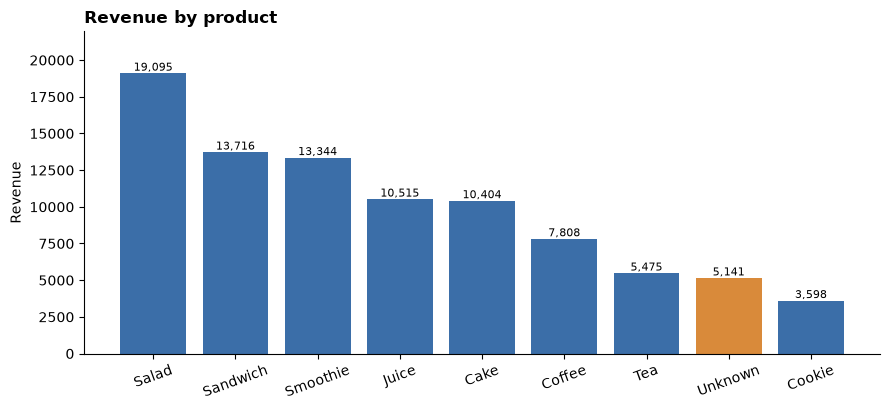

In [12]:
k1 = revenue_by(clean, "item")
display(k1)
bar(k1["item"], k1["revenue"], "Revenue by product", rotate=20,
    colors=[ORANGE if i == UNKNOWN_LABEL else BLUE for i in k1["item"]])

Salad leads on revenue without being the volume leader, because at 5.00 it is the most
expensive item. The orange bar is the revenue that could not be attributed to a product.

## KPI 2: Revenue by location

,location,revenue,transactions,units,revenue_share_pct,avg_transaction_value
0,Unknown,35369.5,3953,11895,39.7,8.95
1,In-Store,27174.0,3008,9131,30.5,9.03
2,Takeaway,26552.5,3016,9144,29.8,8.8


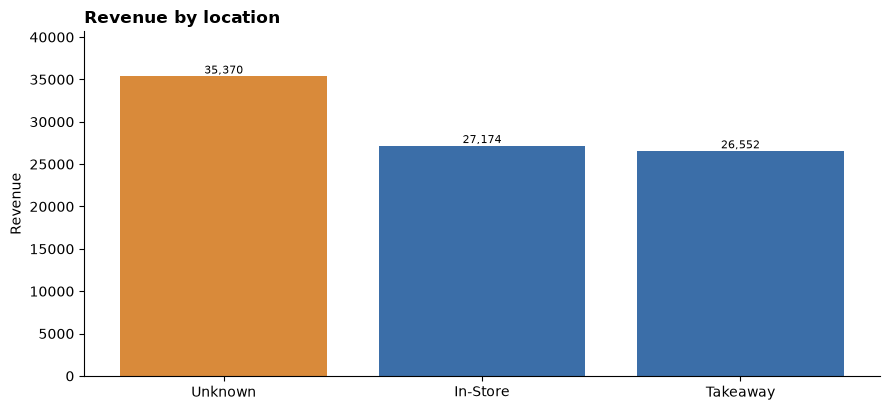

In [13]:
k2 = revenue_by(clean, "location")
display(k2)
bar(k2["location"], k2["revenue"], "Revenue by location",
    colors=[ORANGE if i == UNKNOWN_LABEL else BLUE for i in k2["location"]])

In-Store and Takeaway are level: 30.5% against 29.8%, average transaction 9.03 against
8.80. The finding is that 39.7% of revenue has no location and no arithmetic recovers it.
That has to be fixed at the till.

## KPI 3: Revenue by payment method

,payment_method,revenue,transactions,units,revenue_share_pct,avg_transaction_value
0,Unknown,27813.5,3169,9550,31.22,8.78
1,Credit Card,20466.0,2269,6846,22.97,9.02
2,Digital Wallet,20414.0,2285,6933,22.91,8.93
3,Cash,20402.5,2254,6841,22.9,9.05


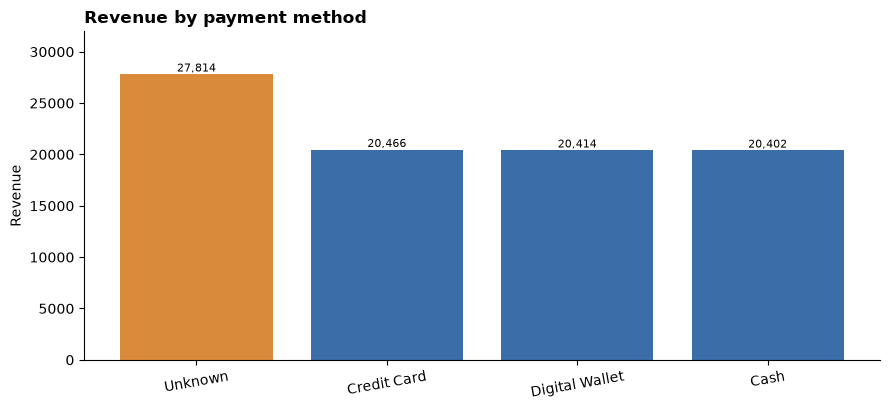

In [14]:
k3 = revenue_by(clean, "payment_method")
display(k3)
bar(k3["payment_method"], k3["revenue"], "Revenue by payment method", rotate=10,
    colors=[ORANGE if i == UNKNOWN_LABEL else BLUE for i in k3["payment_method"]])

The three known methods split evenly, 22.9% to 23.0% each, with average transaction values
within 0.27 of each other. With 31.2% unattributed the honest answer is that payment method
has no measurable effect on basket size, not a ranking between them.

## KPI 4: Weekend vs weekday sales

,day_type,revenue,transactions,calendar_days,revenue_per_calendar_day
0,Weekday,60595.5,6785,260,233.06
1,Weekend,24327.0,2732,105,231.69


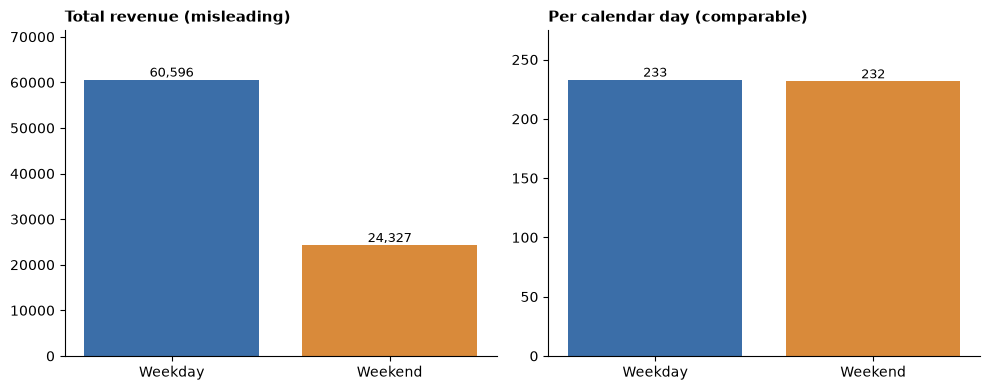

In [15]:
usable = clean[clean.has_revenue & clean.has_valid_date]
k4 = (usable.groupby("day_type")
      .agg(revenue=("total_spent", "sum"),
           transactions=("transaction_id", "count"),
           calendar_days=("transaction_date", "nunique"))
      .sort_values("revenue", ascending=False))
k4["revenue"] = k4["revenue"].round(2)
k4["revenue_per_calendar_day"] = (k4["revenue"] / k4["calendar_days"]).round(2)
k4 = k4.reset_index()
display(k4)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title in [(axes[0], "revenue", "Total revenue (misleading)"),
                       (axes[1], "revenue_per_calendar_day", "Per calendar day (comparable)")]:
    b = ax.bar(k4["day_type"], k4[col], color=[BLUE, ORANGE])
    ax.set_title(title, fontsize=11, weight="bold", loc="left")
    ax.spines[["top", "right"]].set_visible(False)
    ax.margins(y=0.18)
    for bb, v in zip(b, k4[col]):
        ax.annotate(f"{v:,.0f}", (bb.get_x() + bb.get_width() / 2, v),
                    ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

The easiest KPI to get wrong. Weekdays show about 2.5 times the revenue of weekends, but
the year has 260 weekdays and only 105 weekend days. Per calendar day the two are within
0.6% of each other, 233.06 against 231.69.

So there is no weekday advantage, there are just more weekdays. Groups of different sizes
have to be divided by their size before being compared.

## KPI 5: Peak sales day

busiest calendar date : 2023-07-24 (371.50)
strongest day of week : Thursday (12,401.50)


,day_of_week,revenue,transactions
0,Thursday,12401.5,1376
1,Friday,12334.0,1383
2,Sunday,12287.5,1378
3,Monday,12140.0,1379
4,Saturday,12039.5,1354
5,Tuesday,12039.5,1308
6,Wednesday,11680.5,1339


,date,revenue,transactions
0,2023-07-24,371.5,39
1,2023-06-16,367.5,40
2,2023-01-05,363.5,38
3,2023-11-07,360.0,36
4,2023-06-06,355.5,33
5,2023-04-30,353.0,36
6,2023-09-06,349.5,35
7,2023-10-19,341.5,33
8,2023-01-12,338.5,36
9,2023-08-26,334.0,34


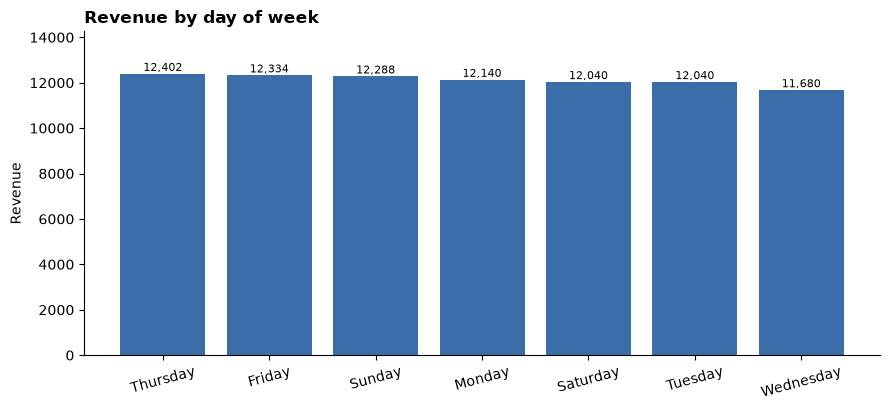

In [16]:
by_date = (usable.groupby(usable["transaction_date"].dt.date)
           .agg(revenue=("total_spent", "sum"), transactions=("transaction_id", "count"))
           .round(2).sort_values("revenue", ascending=False))
by_dow = (usable.groupby("day_of_week")
          .agg(revenue=("total_spent", "sum"), transactions=("transaction_id", "count"))
          .round(2).sort_values("revenue", ascending=False))

print(f"busiest calendar date : {by_date.index[0]} ({by_date.iloc[0]['revenue']:,.2f})")
print(f"strongest day of week : {by_dow.index[0]} ({by_dow.iloc[0]['revenue']:,.2f})")
display(by_dow.reset_index())
display(by_date.head(10).reset_index(names="date"))

bar(by_dow.index, by_dow["revenue"], "Revenue by day of week", rotate=15)

"Peak sales day" can mean the busiest single date or the strongest day of the week, so both
are here.

Neither shows much of a pattern. The best weekday beats the worst by 6%, and the top date
beats the tenth-best by 11%. That is ordinary variation, so there is no weekly rhythm to
staff around.

## KPI 6: Best selling item (by quantity)

best seller, all rows         : Coffee (3,904.0 units)
best seller, source names only : Coffee (3,536 units)


,item,units,transactions,units_share_pct,units_named_in_source,units_from_recovered_names
0,Coffee,3904,1286,13.60,3536,368
1,Salad,3819,1270,13.30,3469,350
2,Tea,3650,1206,12.71,3307,343
3,Cookie,3598,1211,12.53,3232,366
4,Juice,3505,1168,12.21,3505,0
5,Cake,3468,1138,12.08,3468,0
6,Sandwich,3429,1127,11.94,3429,0
7,Smoothie,3336,1094,11.62,3336,0


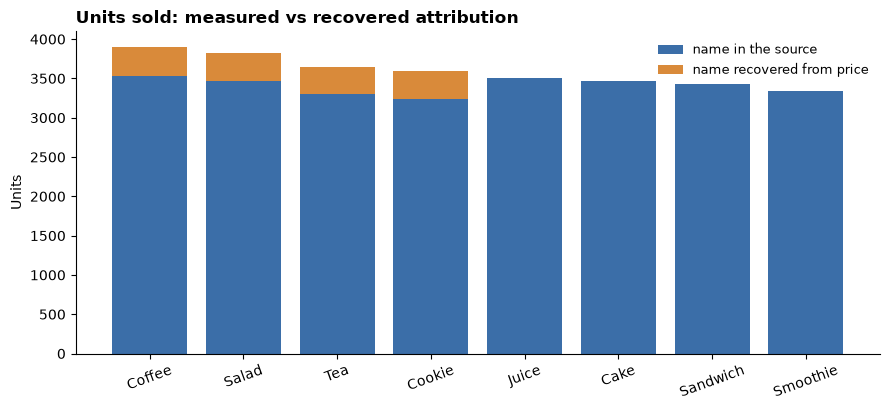

In [17]:
sold = clean[clean.has_valid_quantity & (clean["item"] != UNKNOWN_LABEL)]
k6 = (sold.groupby("item")
      .agg(units=("quantity", "sum"), transactions=("transaction_id", "count"))
      .sort_values("units", ascending=False))
k6["units"] = k6["units"].astype("int64")
k6["units_share_pct"] = (k6["units"] / k6["units"].sum() * 100).round(2)

# Split measured from recovered attribution, because the repair is uneven by item.
direct = sold[~sold["item_recovered"]].groupby("item")["quantity"].sum()
k6["units_named_in_source"] = k6.index.map(direct).astype("float").astype("int64")
k6["units_from_recovered_names"] = k6["units"] - k6["units_named_in_source"]

print(f"best seller, all rows         : {k6.index[0]} ({k6.iloc[0]['units']:,} units)")
print(f"best seller, source names only : {direct.idxmax()} ({int(direct.max()):,} units)")
display(k6.reset_index())

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(k6.index, k6["units_named_in_source"], color=BLUE, label="name in the source")
ax.bar(k6.index, k6["units_from_recovered_names"], bottom=k6["units_named_in_source"],
       color=ORANGE, label="name recovered from price")
ax.set_title("Units sold: measured vs recovered attribution", fontsize=12, weight="bold", loc="left")
ax.set_ylabel("Units")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", rotation=20)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

Coffee wins, but the orange segments are why the rest of the ranking needs care.

Only the four uniquely priced items (Coffee 2.00, Cookie 1.00, Tea 1.50, Salad 5.00) can
have a missing name rebuilt from the price. Cake, Juice, Sandwich and Smoothie share prices
with each other, so they gain nothing. The first four pick up about 350 units each that the
others cannot.

Coffee also leads on source-named rows only, 3,536 against Salad's 3,469, so the top place
holds. But the items sell within about 2% of each other, so the middle of this ranking is a
side effect of the repair rather than customer behaviour.

## KPI 7: Product revenue contribution (%)

,item,revenue,revenue_share_pct,cumulative_share_pct
0,Salad,19095.0,22.74,22.74
1,Sandwich,13716.0,16.34,39.08
2,Smoothie,13344.0,15.89,54.97
3,Juice,10515.0,12.52,67.49
4,Cake,10404.0,12.39,79.88
5,Coffee,7808.0,9.3,89.18
6,Tea,5475.0,6.52,95.7
7,Cookie,3598.0,4.29,99.99


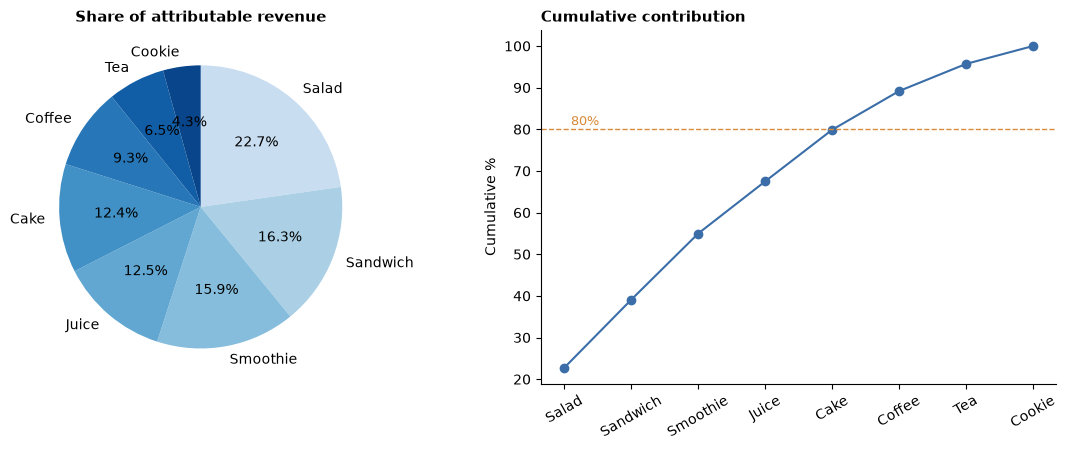

In [18]:
k7 = revenue_by(clean[clean["item"] != UNKNOWN_LABEL], "item")
k7["cumulative_share_pct"] = k7["revenue_share_pct"].cumsum().round(2)
display(k7[["item", "revenue", "revenue_share_pct", "cumulative_share_pct"]])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].pie(k7["revenue_share_pct"], labels=k7["item"], autopct="%1.1f%%",
            startangle=90, counterclock=False, colors=plt.cm.Blues(range(60, 260, 25)))
axes[0].set_title("Share of attributable revenue", fontsize=11, weight="bold")
axes[1].plot(k7["item"], k7["cumulative_share_pct"], marker="o", color=BLUE)
axes[1].axhline(80, color=ORANGE, ls="--", lw=1)
axes[1].annotate("80%", (0.1, 81), color=ORANGE, fontsize=9)
axes[1].set_title("Cumulative contribution", fontsize=11, weight="bold", loc="left")
axes[1].set_ylabel("Cumulative %")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

These shares are of attributable revenue only, so the question is how much of the revenue I
can attribute each item drives.

There is no 80/20 effect. Five of the eight items are needed to reach 79.9%, where a classic
Pareto split gets there in about two. Revenue is spread evenly across the menu, so there is
no small group of products to protect or drop.

## KPI 8: Transaction success rate

analytics-ready : 90.64%  (9,064)
revenue-usable  : 99.77%  (9,977)
arrived clean   : 3,089
arrived damaged : 6,911
cells rebuilt   : 1,462


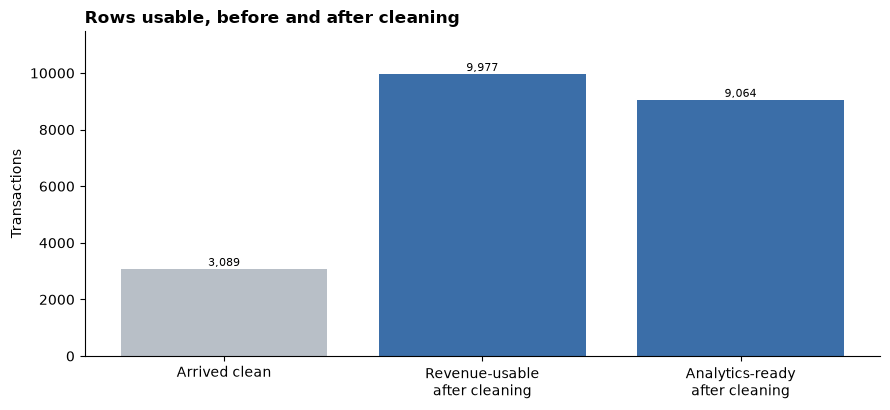

In [19]:
rows = len(clean)
analytics_ready = int(clean["is_valid"].sum())
revenue_usable = int(clean["has_revenue"].sum())
arrived_clean = rows - rows_with_any_missing_raw

print(f"analytics-ready : {analytics_ready / rows * 100:5.2f}%  ({analytics_ready:,})")
print(f"revenue-usable  : {revenue_usable / rows * 100:5.2f}%  ({revenue_usable:,})")
print(f"arrived clean   : {arrived_clean:,}")
print(f"arrived damaged : {rows_with_any_missing_raw:,}")
print(f"cells rebuilt   : {cells_recovered:,}")

bar(["Arrived clean", "Revenue-usable\nafter cleaning", "Analytics-ready\nafter cleaning"],
    [arrived_clean, revenue_usable, analytics_ready],
    "Rows usable, before and after cleaning", ylabel="Transactions",
    colors=[GREY, BLUE, BLUE])

"Success" needs two definitions, because it depends on the question:

- **Analytics-ready, 90.6%.** Item, quantity, price, total and date all real and consistent.
- **Revenue-usable, 99.8%.** `total_spent` can be trusted.

The jump from 3,089 rows arriving clean to 9,977 usable is what the cleaning is worth.

The definition I avoided: failing a row because `location` or `payment_method` is missing.
Those are labels rather than facts, and including them drops about two thirds of the data,
which changes the answers instead of just making them less precise.

## KPI 9: Missing data rate

cell level : 12.60%  (10,082 of 80,000)
row level  : 69.11%  (6,911 rows)


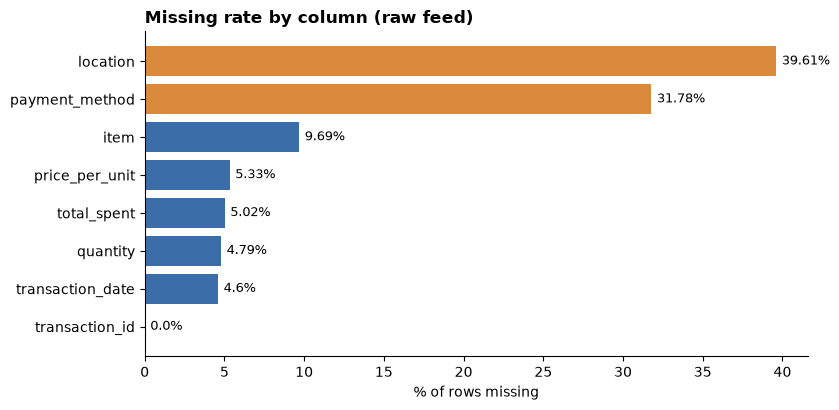

In [20]:
total_cells = int(raw_normalised.size)
print(f"cell level : {missing_cells_raw / total_cells * 100:.2f}%  ({missing_cells_raw:,} of {total_cells:,})")
print(f"row level  : {rows_with_any_missing_raw / len(raw) * 100:.2f}%  ({rows_with_any_missing_raw:,} rows)")

by_col = (missing_by_column_raw / len(raw) * 100).round(2).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.barh(by_col.index, by_col.values, color=[ORANGE if v > 20 else BLUE for v in by_col.values])
ax.set_title("Missing rate by column (raw feed)", fontsize=12, weight="bold", loc="left")
ax.set_xlabel("% of rows missing")
ax.spines[["top", "right"]].set_visible(False)
for y, v in enumerate(by_col.values):
    ax.annotate(f"{v}%", (v, y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
plt.tight_layout()
plt.show()

12.6% of cells but 69.1% of rows. Both numbers belong in the report, since the cell figure
on its own makes the problem sound five times smaller than it is.

The two orange bars are the unrecoverable columns and 71% of all missing cells.
`transaction_id` at 0% is what made the duplicate check safe.

## KPI 10: Invalid date percentage

unusable dates    : 4.60%  (460 of 10,000)
  blank/sentinel  : 460
  malformed       : 0
valid range       : 2023-01-01 to 2023-12-31


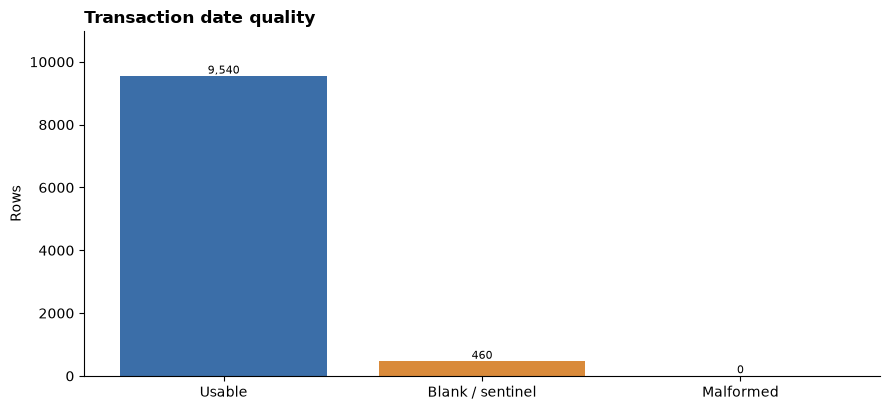

In [21]:
date_col = raw_normalised["transaction_date"]
parsed = pd.to_datetime(date_col, format="%Y-%m-%d", errors="coerce")
invalid = int(parsed.isna().sum())

print(f"unusable dates    : {invalid / len(raw) * 100:.2f}%  ({invalid:,} of {len(raw):,})")
print(f"  blank/sentinel  : {int(date_col.isna().sum()):,}")
print(f"  malformed       : {int((date_col.notna() & parsed.isna()).sum()):,}")
print(f"valid range       : {parsed.min().date()} to {parsed.max().date()}")

bar(["Usable", "Blank / sentinel", "Malformed"],
    [len(raw) - invalid, int(date_col.isna().sum()), int((date_col.notna() & parsed.isna()).sum())],
    "Transaction date quality", ylabel="Rows", colors=[BLUE, ORANGE, GREY])

4.6% of rows have no usable date and all of them are blanks or sentinels. None are malformed
or out of range, so the fix upstream is null handling and not date parsing.

The valid dates cover all of 2023 with no gaps, so the loss is spread across the year and
the time-based KPIs stay usable.

# Summary

In [22]:
summary = pd.DataFrame([
    ("1. Revenue by product", f"{k1.iloc[0]['item']} leads, {k1.iloc[0]['revenue']:,.0f} ({k1.iloc[0]['revenue_share_pct']}%)"),
    ("2. Revenue by location", f"In-Store {k2.set_index('location').loc['In-Store','revenue_share_pct']}% vs Takeaway {k2.set_index('location').loc['Takeaway','revenue_share_pct']}%, {k2.set_index('location').loc['Unknown','revenue_share_pct']}% unknown"),
    ("3. Revenue by payment method", "three methods within 0.1pp of each other, about 23% each"),
    ("4. Weekend vs weekday", f"per day {k4.set_index('day_type').loc['Weekday','revenue_per_calendar_day']:,.2f} vs {k4.set_index('day_type').loc['Weekend','revenue_per_calendar_day']:,.2f}, no real difference"),
    ("5. Peak sales day", f"{by_date.index[0]}, {by_dow.index[0]} by weekday, neither significant"),
    ("6. Best selling item", f"{k6.index[0]}, {k6.iloc[0]['units']:,} units, thin margin"),
    ("7. Product revenue contribution", "flat, 5 of 8 items to reach 80%"),
    ("8. Transaction success rate", f"{analytics_ready / rows * 100:.1f}% analytics-ready, {revenue_usable / rows * 100:.1f}% revenue-usable"),
    ("9. Missing data rate", f"{missing_cells_raw / total_cells * 100:.1f}% of cells, {rows_with_any_missing_raw / len(raw) * 100:.1f}% of rows"),
    ("10. Invalid date percentage", f"{invalid / len(raw) * 100:.1f}%, all blanks or sentinels"),
], columns=["KPI", "Answer"])
summary

,KPI,Answer
0,1. Revenue by product,"Salad leads, 19,095 (21.43%)"
1,2. Revenue by location,"In-Store 30.5% vs Takeaway 29.8%, 39.7% unknown"
2,3. Revenue by payment method,"three methods within 0.1pp of each other, abou..."
3,4. Weekend vs weekday,"per day 233.06 vs 231.69, no real difference"
4,5. Peak sales day,"2023-07-24, Thursday by weekday, neither signi..."
5,6. Best selling item,"Coffee, 3,904.0 units, thin margin"
6,7. Product revenue contribution,"flat, 5 of 8 items to reach 80%"
7,8. Transaction success rate,"90.6% analytics-ready, 99.8% revenue-usable"
8,9. Missing data rate,"12.6% of cells, 69.1% of rows"
9,10. Invalid date percentage,"4.6%, all blanks or sentinels"


### What I took from this

- **Dirty is not the same as lost.** 69% of rows arrived damaged and 99.8% ended up usable,
  because the data repeats itself. Look for that redundancy before reaching for `dropna()`.
- **The definition of valid decides the answers.** Requiring a non-null `location` would
  drop 68% of rows and change which product and which day come out on top.
- **Divide by exposure before comparing groups.** Weekend against weekday looks like 2.5x
  and is really 0.6%.
- **Keep track of what was repaired.** Without the `item_recovered` flag, KPI 6's ranking
  looks like customer behaviour when part of it is a side effect of the repair.
- **Never let `Unknown` win a category.** It belongs in a revenue table as a visible gap,
  not in best-selling item.
- **Check assumptions against the data.** Zero mismatches in 8,544 rows is what made the
  arithmetic repair defensible.